In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
def _build_method_label(df_part):
    if 'ml_model' in df_part.columns:
        return df_part['ml_model'] + " | " + df_part["method"] + " (" + df_part["params"].astype(str) + ")"
    return df_part["method"] + " (" + df_part["params"].astype(str) + ")"


def _filter_by_methods(df, dataset, mechanism, methods_config):
    subsets = []
    for method, params_list in methods_config.items():
        for params in params_list:
            subset = df[
                (df["dataset"] == dataset) &
                (df["mechanism"] == mechanism) &
                (df["method"] == method) &
                (df["params"] == params)
            ]
            if not subset.empty:
                subsets.append(subset)

    if not subsets:
        return pd.DataFrame()

    return pd.concat(subsets).copy()


def plot_experiment_results(
    df,
    dataset,
    mechanism,
    methods_config,
    metrics,
    show_std=True,
    ml_model=None,
    title_suffix=None,
    legend_ncol=2
    ):
    """
    Универсальная функция отрисовки результатов.

    Параметры:
    - df: DataFrame с результатами экспериментов
    - dataset: название датасета (например "housing")
    - mechanism: название механизма пропусков (например "MCAR")
    - methods_config: dict, например {"MICE hybrid": ["max_iter=10"]}
    - metrics: list метрик, например ["nrmse", "accuracy"]
    - show_std: если True и есть колонки <metric>_std, рисуем область mean ± std
    - ml_model: фильтр по модели (например "RandomForest" или "Ridge").
      Если None, отображаются все модели (если колонка ml_model есть).
    - title_suffix: дополнительный текст в заголовке
    - legend_ncol: число колонок в легенде
    """
    plot_df = _filter_by_methods(df, dataset, mechanism, methods_config)

    if plot_df.empty:
        print("Нет данных под выбранные конфиги")
        return

    if ml_model is not None and "ml_model" in plot_df.columns:
        plot_df = plot_df[plot_df["ml_model"] == ml_model].copy()
        if plot_df.empty:
            print(f"Нет данных для ml_model={ml_model}")
            return

    plot_df["method_params"] = _build_method_label(plot_df)

    # создаем сетку графиков
    n_metrics = len(metrics)
    n_cols = min(3, n_metrics)
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    ordered_labels = sorted(plot_df["method_params"].unique())
    palette = dict(zip(ordered_labels, sns.color_palette(n_colors=len(ordered_labels))))

    for i, metric in enumerate(metrics):
        ax = axes[i]

        sns.lineplot(
            data=plot_df,
            x="ratio",
            y=metric,
            hue="method_params",
            hue_order=ordered_labels,
            palette=palette,
            marker="o",
            linewidth=2,
            ax=ax
        )

        std_col = f"{metric}_std"
        if show_std and std_col in plot_df.columns:
            for label, grp in plot_df.groupby("method_params"):
                grp = grp.sort_values("ratio")
                y = grp[metric].astype(float)
                y_std = grp[std_col].fillna(0).astype(float)
                ax.fill_between(
                    grp["ratio"].astype(float),
                    y - y_std,
                    y + y_std,
                    color=palette[label],
                    alpha=0.18
                )

        ax.set_title(metric.upper())
        ax.set_xlabel("Missing Ratio")
        ax.set_ylabel(metric)
        ax.grid(True, linestyle="--", alpha=0.7)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # удаляем пустые оси, если метрик меньше, чем subplot-ов
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    # общая легенда
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=legend_ncol,
        title="Method & Params",
        frameon=True
    )

    top_margin = 0.88 if (n_rows == 1 and n_cols == 3) else 0.92
    plt.tight_layout(rect=[0, 0.08, 1, top_margin])

    title = f"{dataset} ({mechanism})"
    if ml_model is not None:
        title += f" | model={ml_model}"
    if title_suffix:
        title += f" | {title_suffix}"
    fig.suptitle(title, fontsize=16, y=0.99)

    plt.show()


def plot_model_results_compact(
    df_models,
    dataset,
    methods_config,
    metrics,
    ml_model,
    mechanisms=("MCAR", "MAR"),
    show_std=True
    ):
    """
    Компактная визуализация для отчета: одна фигура для выбранной модели,
    строки = механизмы пропусков, столбцы = метрики.
    """
    mechanisms = list(mechanisms)
    n_rows = len(mechanisms)
    n_cols = len(metrics)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 4.6 * n_rows),
        squeeze=False
    )

    for r, mechanism in enumerate(mechanisms):
        plot_df = _filter_by_methods(df_models, dataset, mechanism, methods_config)
        if plot_df.empty:
            for c in range(n_cols):
                axes[r, c].set_visible(False)
            continue

        if "ml_model" in plot_df.columns:
            plot_df = plot_df[plot_df["ml_model"] == ml_model].copy()

        if plot_df.empty:
            for c in range(n_cols):
                axes[r, c].set_visible(False)
            continue

        plot_df["method_params"] = plot_df["method"] + " (" + plot_df["params"].astype(str) + ")"
        ordered_labels = sorted(plot_df["method_params"].unique())
        palette = dict(zip(ordered_labels, sns.color_palette(n_colors=len(ordered_labels))))

        for c, metric in enumerate(metrics):
            ax = axes[r, c]
            sns.lineplot(
                data=plot_df,
                x="ratio", y=metric,
                hue="method_params",
                hue_order=ordered_labels,
                palette=palette,
                marker="o",
                linewidth=2,
                ax=ax
            )

            std_col = f"{metric}_std"
            if show_std and std_col in plot_df.columns:
                for label, grp in plot_df.groupby("method_params"):
                    grp = grp.sort_values("ratio")
                    y = grp[metric].astype(float)
                    y_std = grp[std_col].fillna(0).astype(float)
                    ax.fill_between(
                        grp["ratio"].astype(float),
                        y - y_std,
                        y + y_std,
                        color=palette[label],
                        alpha=0.18
                    )

            ax.set_title(f"{mechanism}: {metric.upper()}")
            ax.set_xlabel("Missing Ratio")
            ax.set_ylabel(metric)
            ax.grid(True, linestyle="--", alpha=0.7)
            if ax.get_legend() is not None:
                ax.get_legend().remove()

    # собираем легенду из первого видимого axes
    legend_ax = None
    for row_axes in axes:
        for ax in row_axes:
            if ax.get_visible():
                legend_ax = ax
                break
        if legend_ax is not None:
            break

    if legend_ax is not None:
        handles, labels = legend_ax.get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.04),
            ncol=min(4, max(1, len(labels))),
            title="Imputation Method",
            frameon=True
        )

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    fig.suptitle(f"{dataset} | model={ml_model}", fontsize=16, y=0.995)
    plt.show()

In [3]:
df_results = pd.read_excel("experiment_results.xlsx")

**Сравнение различных реализаций KNN и MICE**

In [32]:
methods_config = {
    # "KNN numeric": ["n_neighbors=7"],
    # "KNN gower": ["n_neighbors=7"],
    # "KNN hybrid": ["n_neighbors=7"],
    "MICE": ["max_iter=10"],
    "MICE hybrid": ["max_iter=10"],
    "MissForest": ["n_estimators=100"]
}

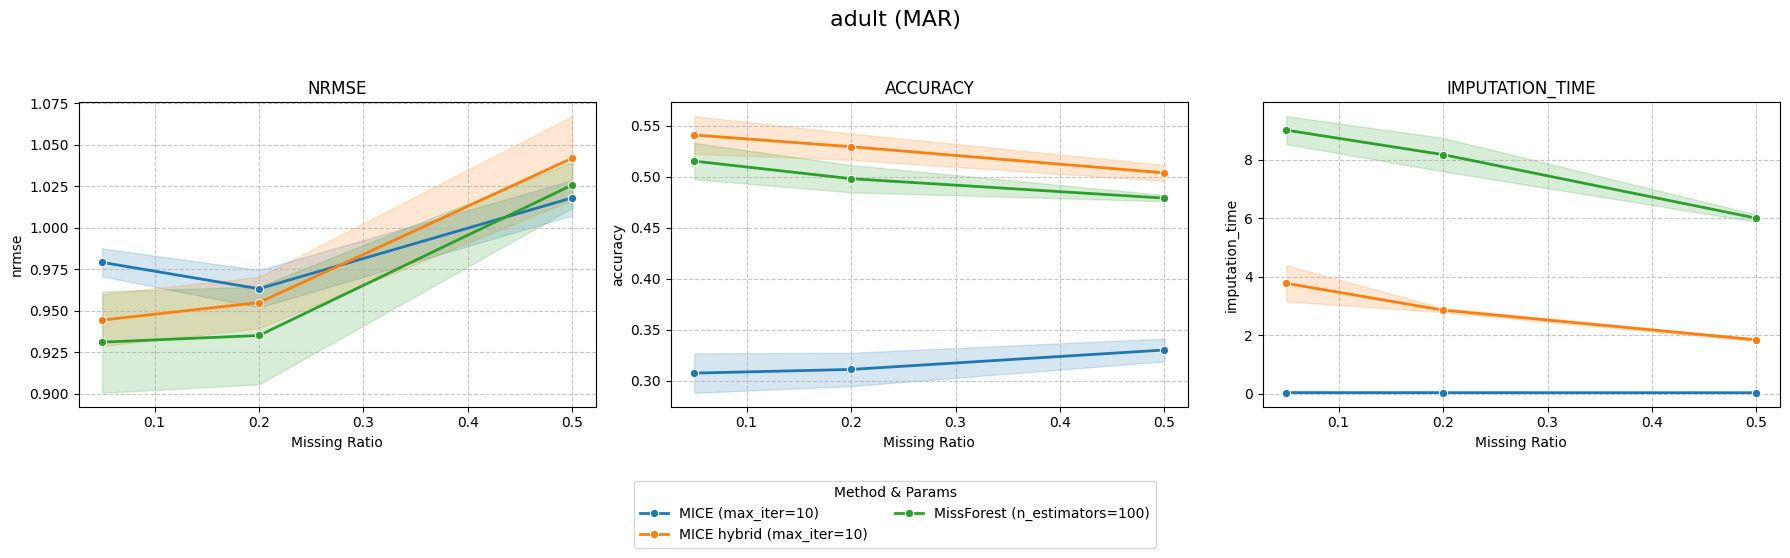

In [36]:
plot_experiment_results(
    df_results,
    dataset="adult",
    mechanism="MAR",
    methods_config=methods_config,
    metrics=["nrmse", "accuracy", "imputation_time"]
)

**Графики для импутации**

In [38]:
methods_config = {
    "Simple": ["num_strategy=mean"],
    "KNN hybrid": ["n_neighbors=7"],
    "MICE hybrid": ["max_iter=10"],
    "MissForest": ["n_estimators=100"]
}

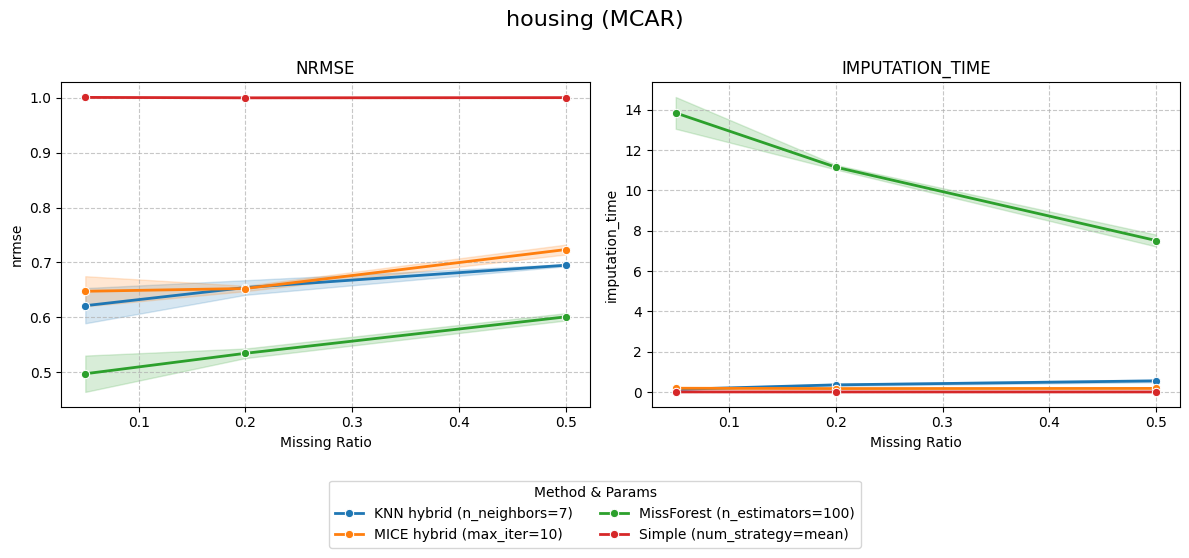

In [39]:
plot_experiment_results(
    df_results,
    dataset="housing",
    mechanism="MCAR",
    methods_config=methods_config,
    metrics=["nrmse", "imputation_time"]
)

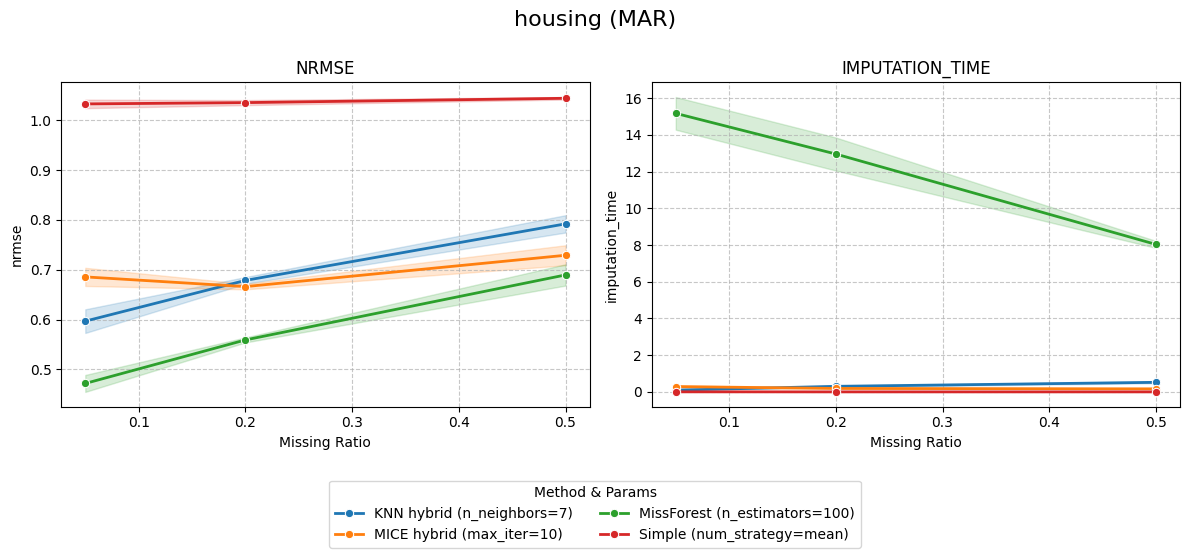

In [41]:
plot_experiment_results(
    df_results,
    dataset="housing",
    mechanism="MAR",
    methods_config=methods_config,
    metrics=["nrmse", "imputation_time"]
)

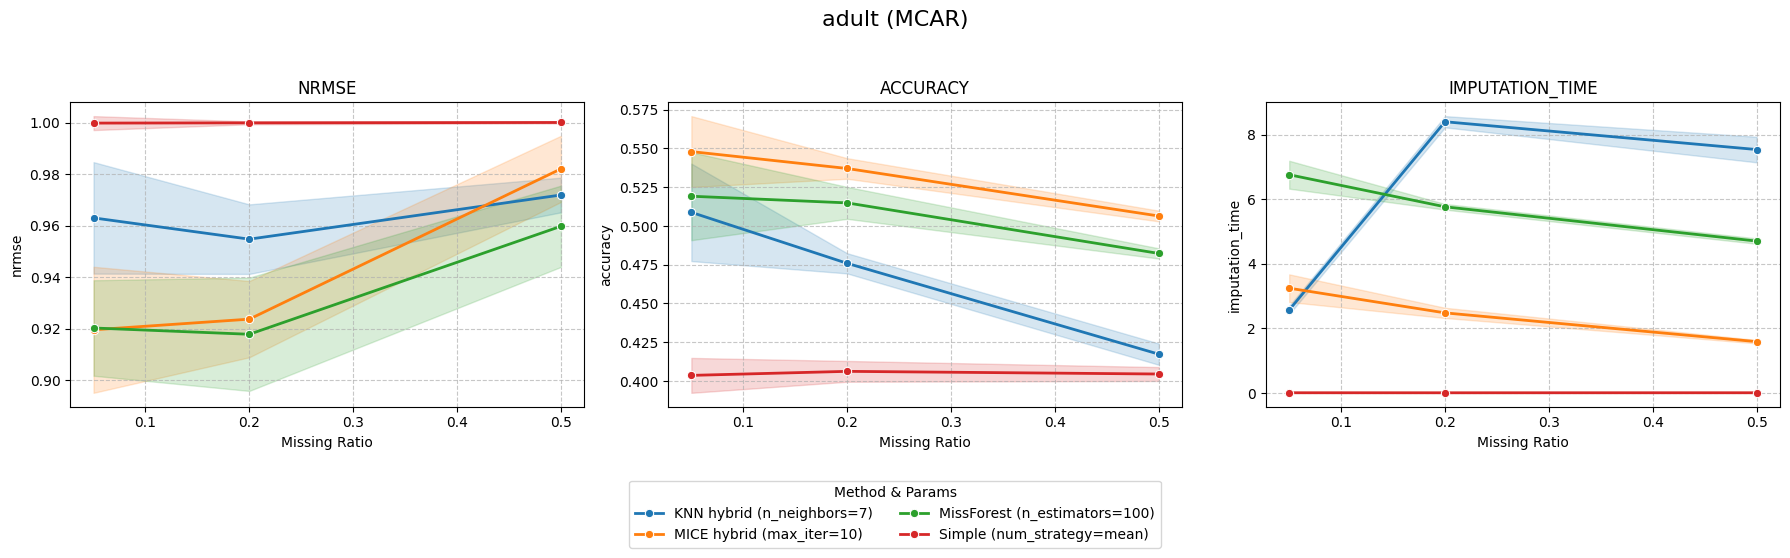

In [42]:
plot_experiment_results(
    df_results,
    dataset="adult",
    mechanism="MCAR",
    methods_config=methods_config,
    metrics=["nrmse", "accuracy", "imputation_time"]
)

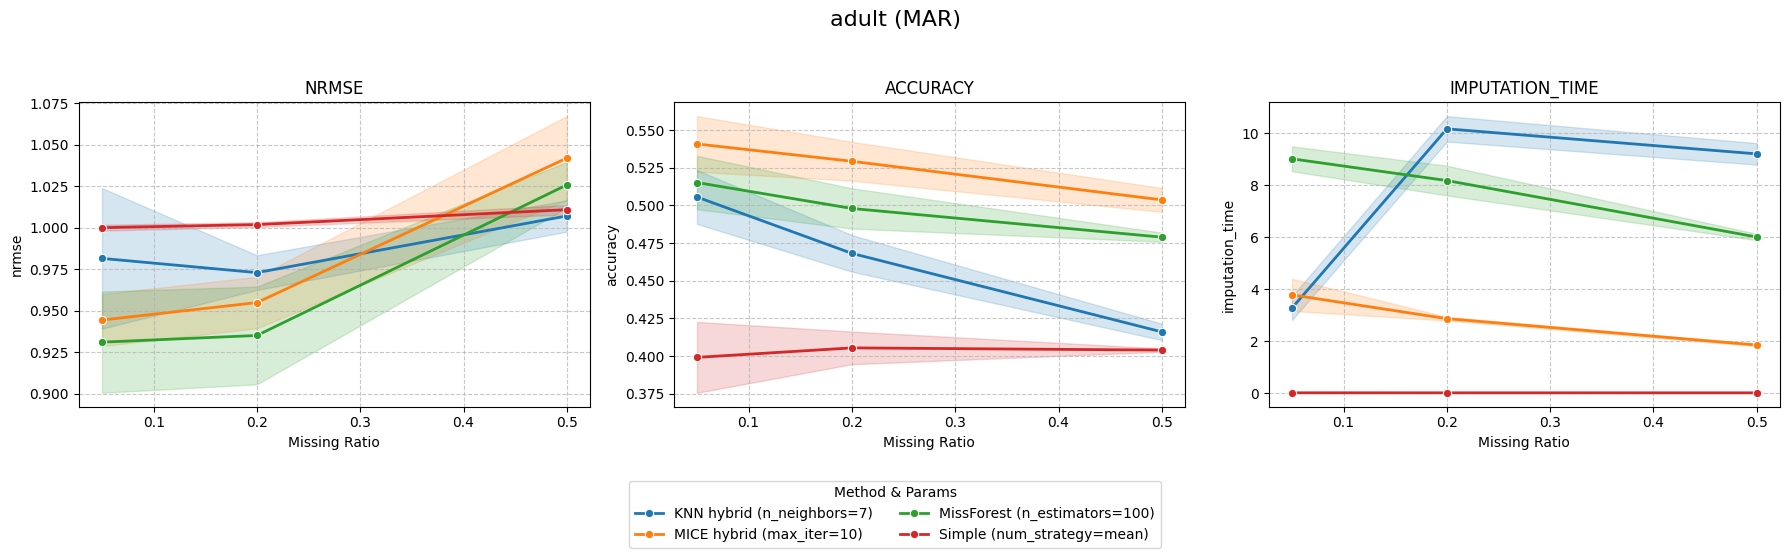

In [43]:
plot_experiment_results(
    df_results,
    dataset="adult",
    mechanism="MAR",
    methods_config=methods_config,
    metrics=["nrmse", "accuracy", "imputation_time"]
)

**Графики для моделей**

In [4]:
df_results_models = pd.read_excel("model_evaluation_results.xlsx")

In [6]:
methods_config = {
    "Simple": ["num_strategy=mean"],
    "KNN hybrid": ["n_neighbors=7"],
    "MICE hybrid": ["max_iter=10"],
    "MissForest": ["n_estimators=100"]
}

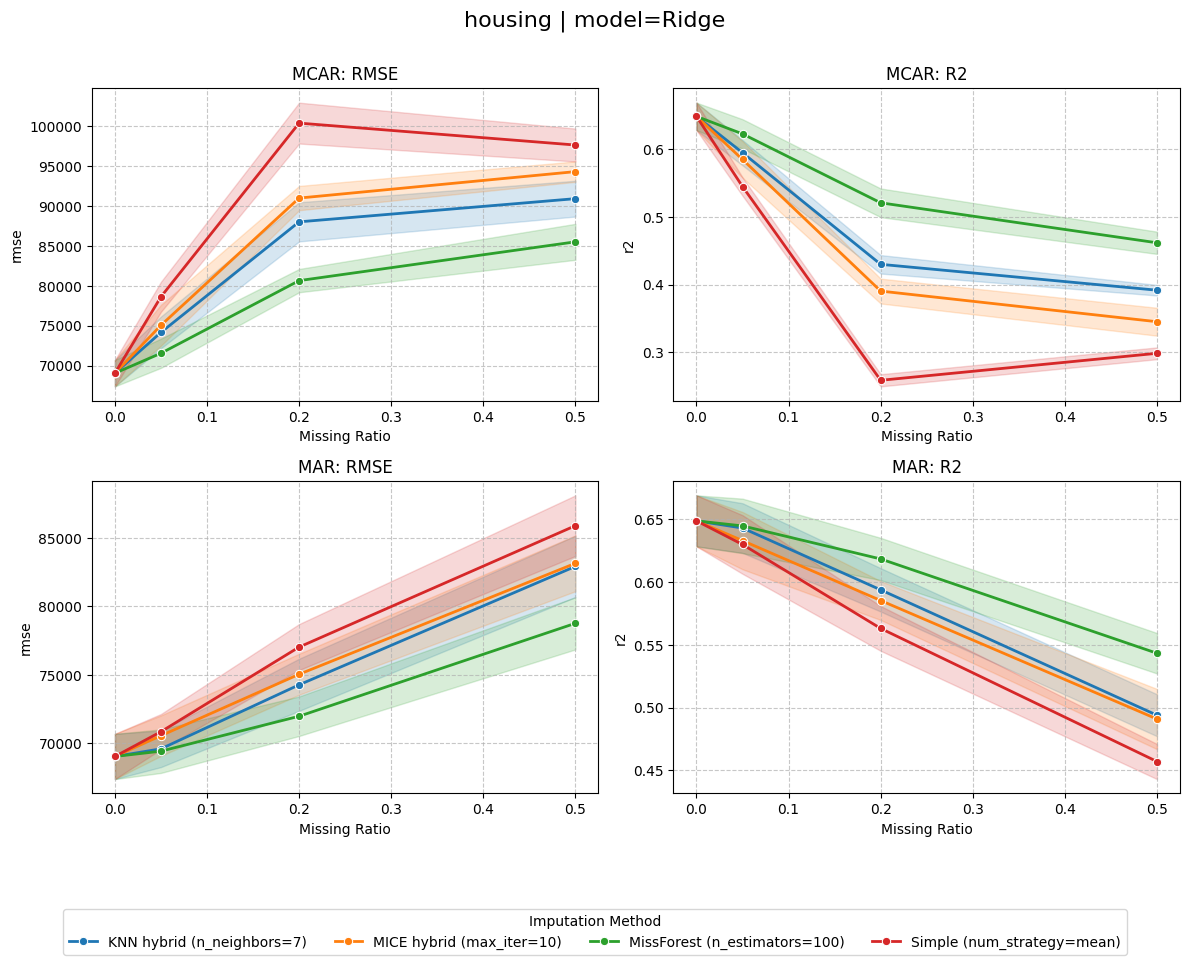

In [10]:
plot_model_results_compact(
    df_models=df_results_models,
    dataset="housing",
    methods_config=methods_config,
    metrics=["rmse", "r2"],
    ml_model="Ridge",
    mechanisms=("MCAR", "MAR")
)

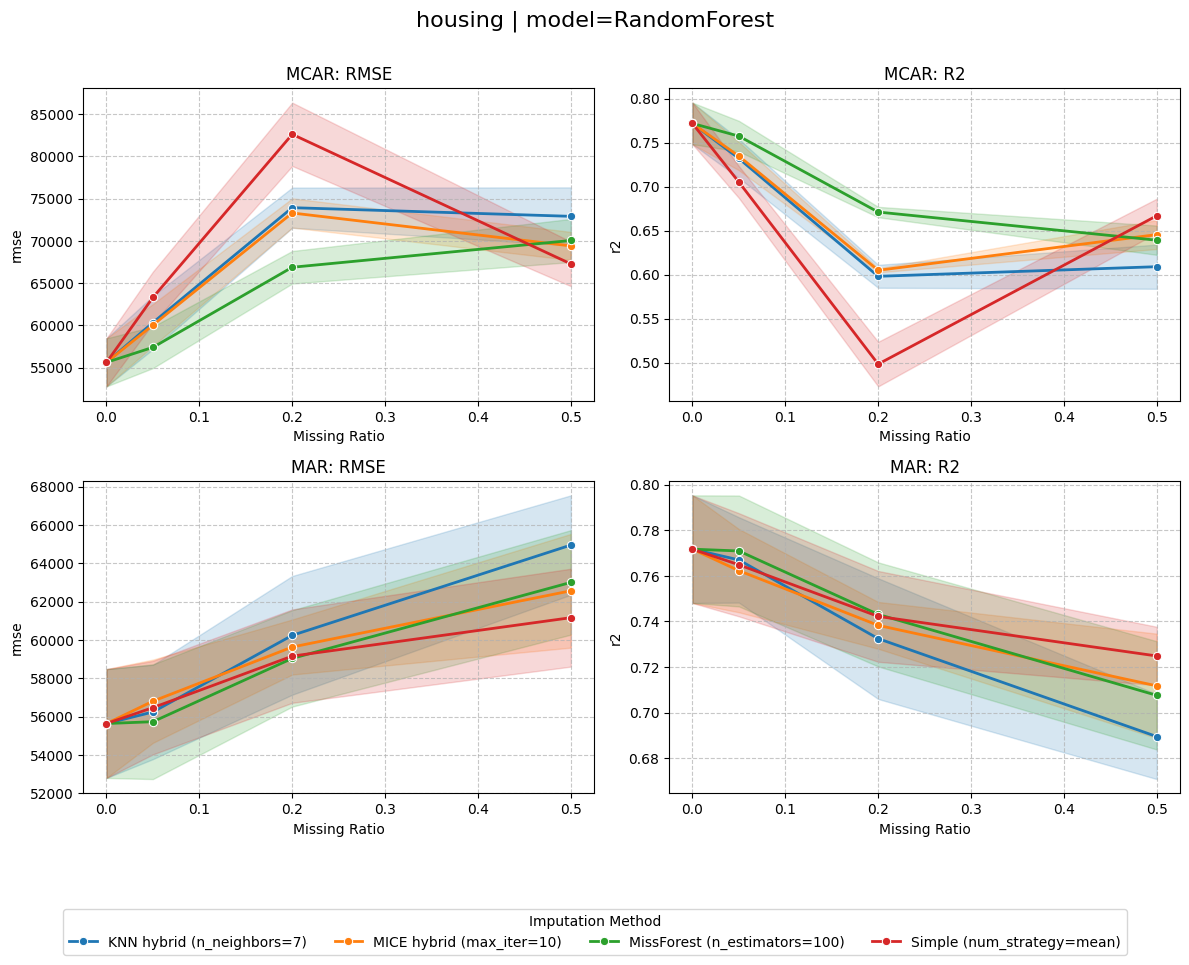

In [11]:
plot_model_results_compact(
    df_models=df_results_models,
    dataset="housing",
    methods_config=methods_config,
    metrics=["rmse", "r2"],
    ml_model="RandomForest",
    mechanisms=("MCAR", "MAR")
)

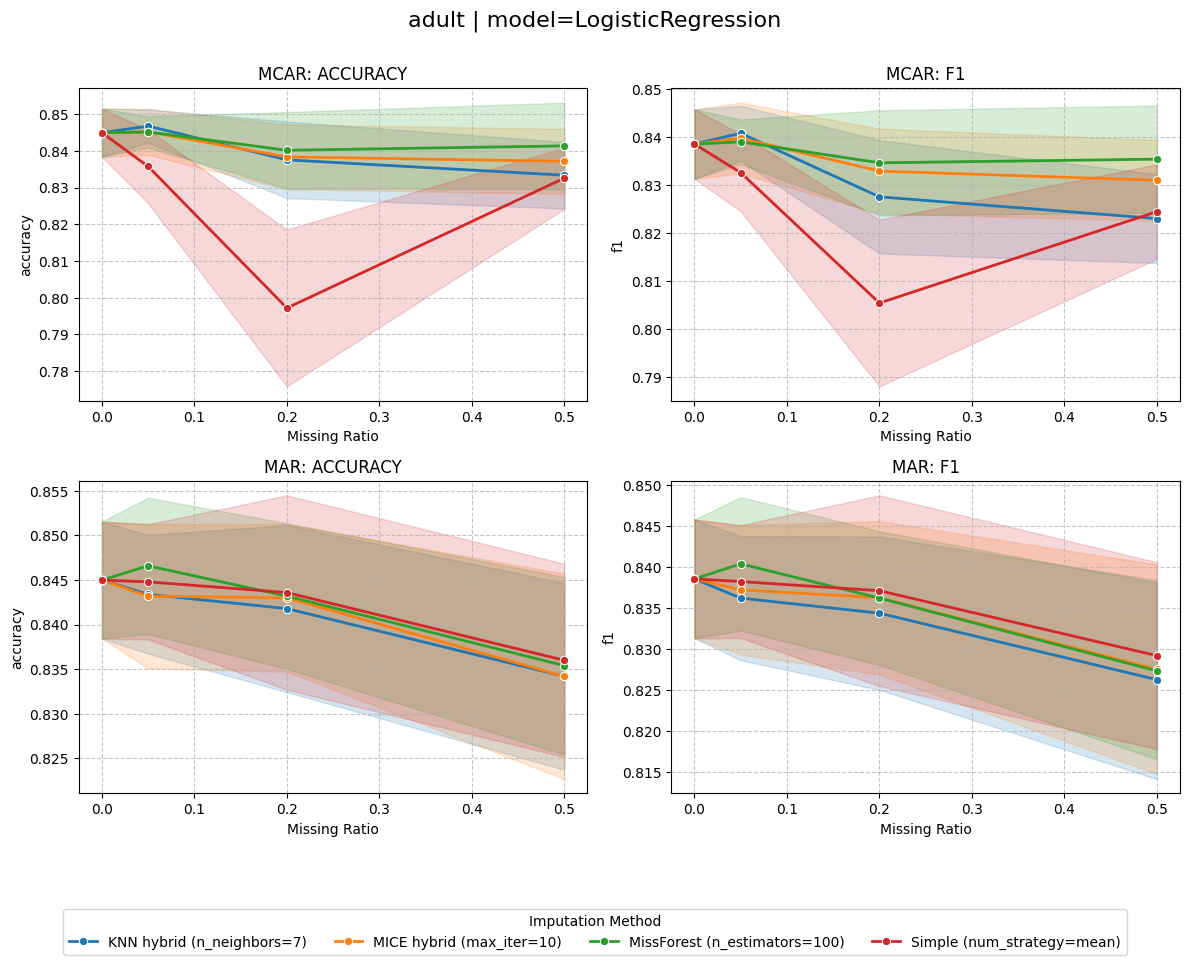

In [13]:
plot_model_results_compact(
    df_models=df_results_models,
    dataset="adult",
    methods_config=methods_config,
    metrics=["accuracy", "f1"],
    ml_model="LogisticRegression",
    mechanisms=("MCAR", "MAR")
)

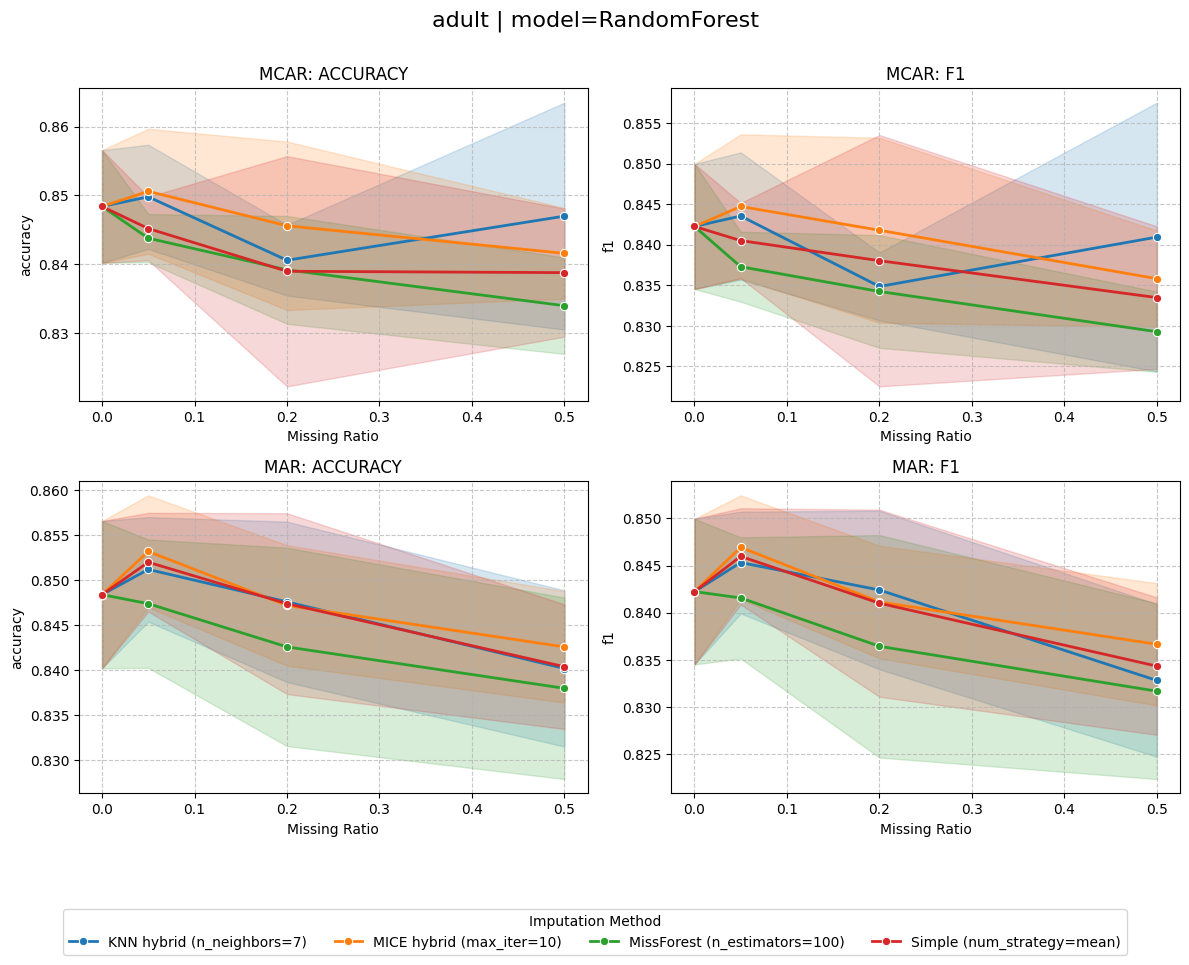

In [14]:
plot_model_results_compact(
    df_models=df_results_models,
    dataset="adult",
    methods_config=methods_config,
    metrics=["accuracy", "f1"],
    ml_model="RandomForest",
    mechanisms=("MCAR", "MAR")
)

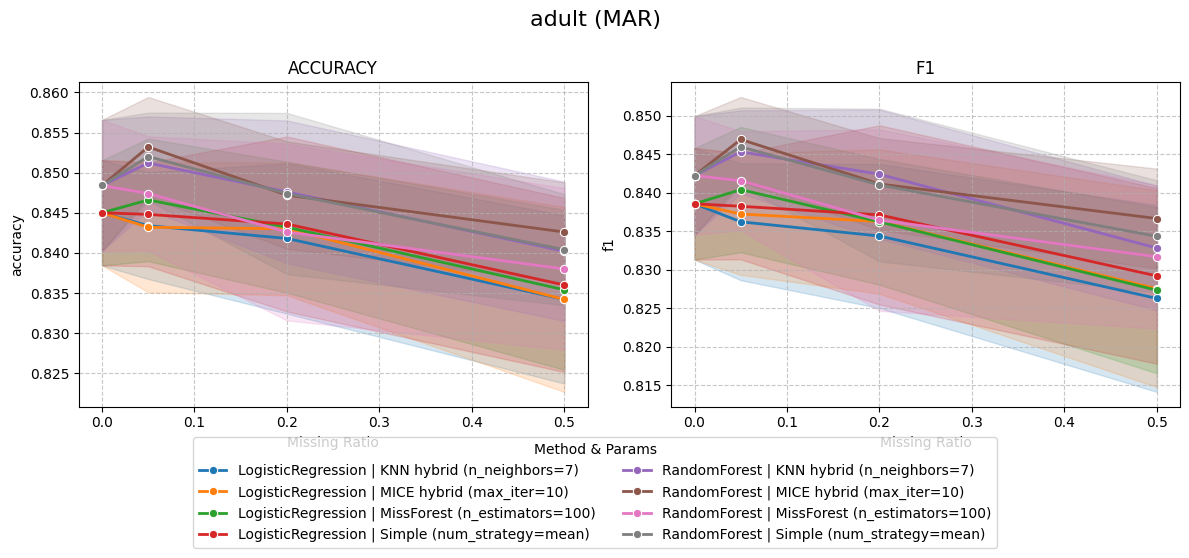

In [48]:
plot_experiment_results(
    df_results_models,
    dataset="adult",
    mechanism="MAR",
    methods_config=methods_config,
    metrics=["accuracy", "f1"]
)

Сравнение реализаций одного метода.

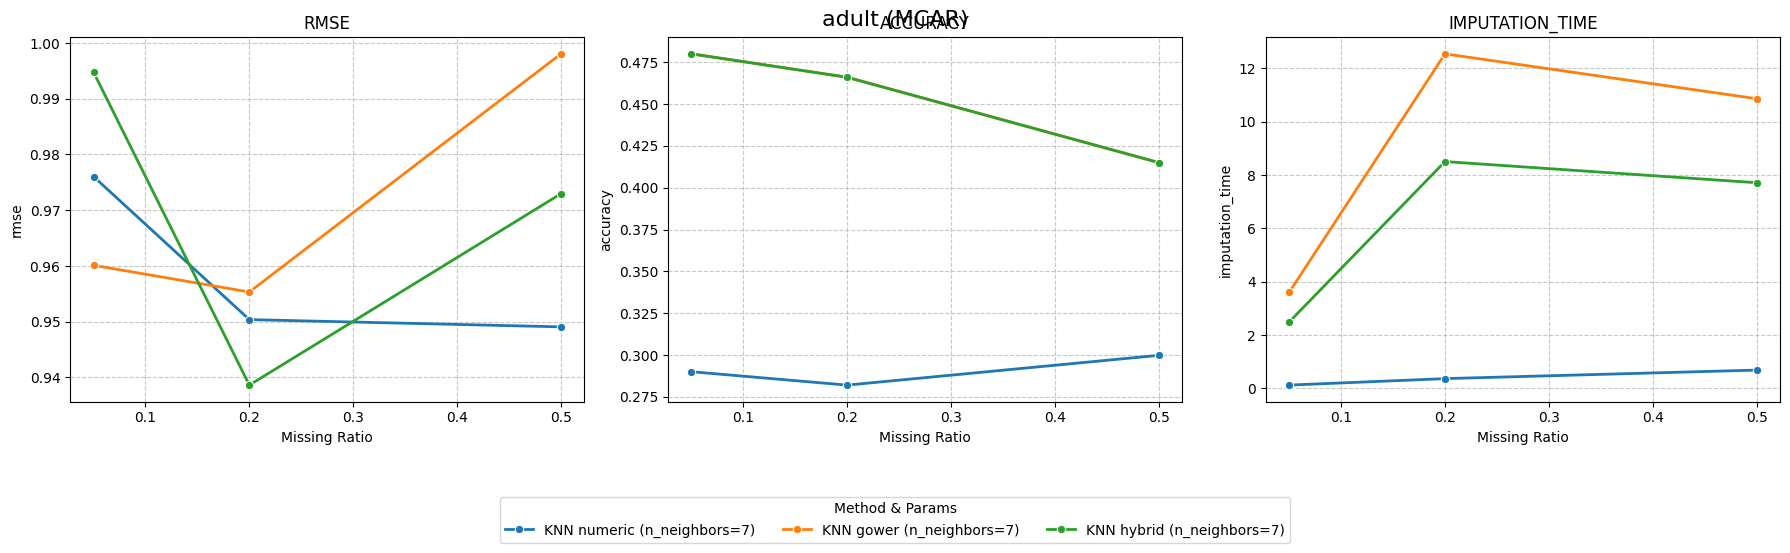

In [16]:
methods_config = {
    "KNN numeric": ["n_neighbors=7"],
    "KNN gower": ["n_neighbors=7"],
    "KNN hybrid": ["n_neighbors=7"],
}

plot_experiment_results(
    df_results,
    dataset="adult",
    mechanism="MCAR",
    methods_config=methods_config,
    metrics=["rmse", "accuracy", "imputation_time"]
)